## Exploratory Data Analysis

> Statistical breakdown of AI vs. human activity, per-person reliance on agents, delegation patterns, and temporal trends across the full 185k-event log.

#### Installs

In [41]:
%pip install networkx matplotlib numpy


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


#### Dependencies & setup

In [42]:
import json
import datetime
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter, defaultdict
import numpy as np

#### 1. Action Breakdown — AI vs. human by event type

> Horizontal stacked bar: each row is an event type, split by AI-agent vs. human involvement. Shows which actions are AI-dominated and which remain human-driven.

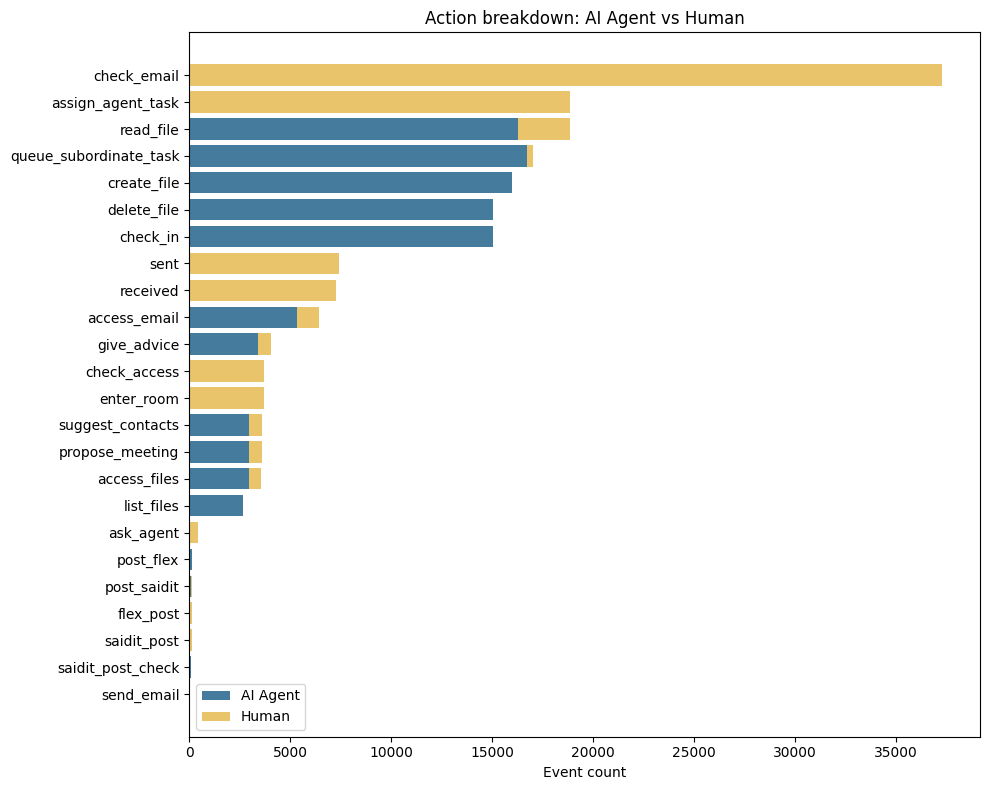

In [43]:
with open("../data/interactions.json") as f:
    events = json.load(f)["events"]

ai_counts = Counter()
human_counts = Counter()
for e in events:
    is_ai = any(p.startswith("Agent/") for p in e["parties"])
    (ai_counts if is_ai else human_counts)[e["short_name"]] += 1

all_types = sorted(
    set(ai_counts) | set(human_counts),
    key=lambda t: ai_counts.get(t, 0) + human_counts.get(t, 0)
)
ai_vals = [ai_counts.get(t, 0) for t in all_types]
hu_vals = [human_counts.get(t, 0) for t in all_types]

y = np.arange(len(all_types))
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(y, ai_vals, color="#457B9D", label="AI Agent")
ax.barh(y, hu_vals, left=ai_vals, color="#E9C46A", label="Human")
ax.set_yticks(y)
ax.set_yticklabels(all_types)
ax.set_xlabel("Event count")
ax.set_title("Action breakdown: AI Agent vs Human")
ax.legend()
plt.tight_layout()
plt.show()

#### 2. AI Reliance — event counts per person

> Per-person stacked bar of AI-agent actions vs. direct human actions, sorted by total volume. Reveals which people rely most heavily on agents and who acts mostly on their own.

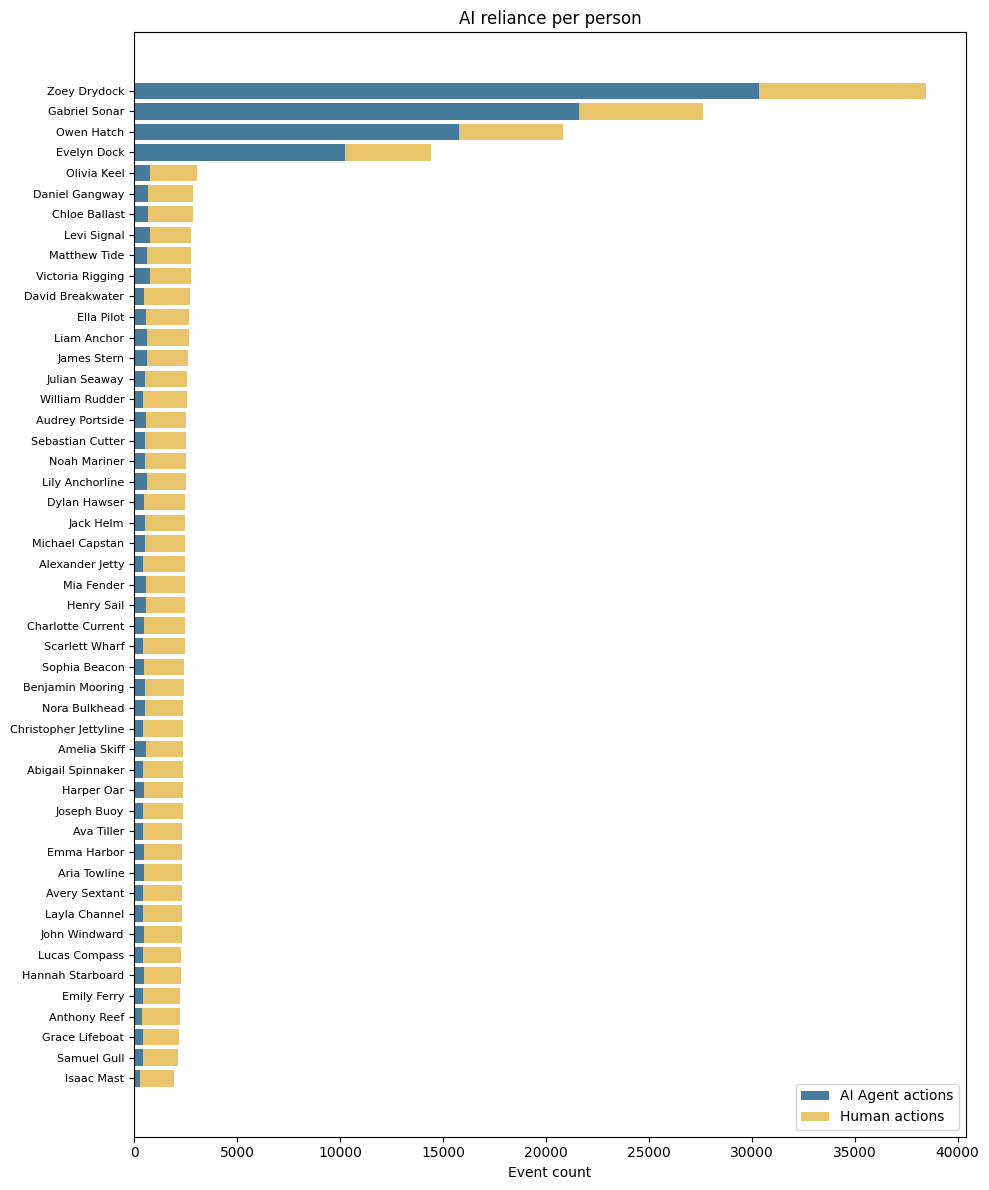

In [44]:
person_human = Counter()
person_ai = Counter()
for e in events:
    for p in e["parties"]:
        if p.startswith("Agent/"):
            person_ai[p.replace("Agent/", "")] += 1
        elif p.startswith("person:"):
            person_human[p] += 1

all_people = sorted(set(person_human) | set(person_ai))
ai_v = [person_ai.get(p, 0) for p in all_people]
hu_v = [person_human.get(p, 0) for p in all_people]
totals = [a + h for a, h in zip(ai_v, hu_v)]
order = np.argsort(totals)
all_people = [all_people[i] for i in order]
ai_v = [ai_v[i] for i in order]
hu_v = [hu_v[i] for i in order]

plabels = [p.replace("person:", "").replace("_", " ").title() for p in all_people]
y3 = np.arange(len(plabels))
fig, ax = plt.subplots(figsize=(10, 12))
ax.barh(y3, ai_v, color="#457B9D", label="AI Agent actions")
ax.barh(y3, hu_v, left=ai_v, color="#E9C46A", label="Human actions")
ax.set_yticks(y3)
ax.set_yticklabels(plabels, fontsize=8)
ax.set_xlabel("Event count")
ax.set_title("AI reliance per person")
ax.legend()
plt.tight_layout()
plt.show()

#### 3. Agent Network — A2A task delegation graph

> Directed graph of `queue_subordinate_task` events between agents. Node size ∝ degree; edge width ∝ delegation count. Shows which agents act as hubs or bottlenecks in the delegation flow.

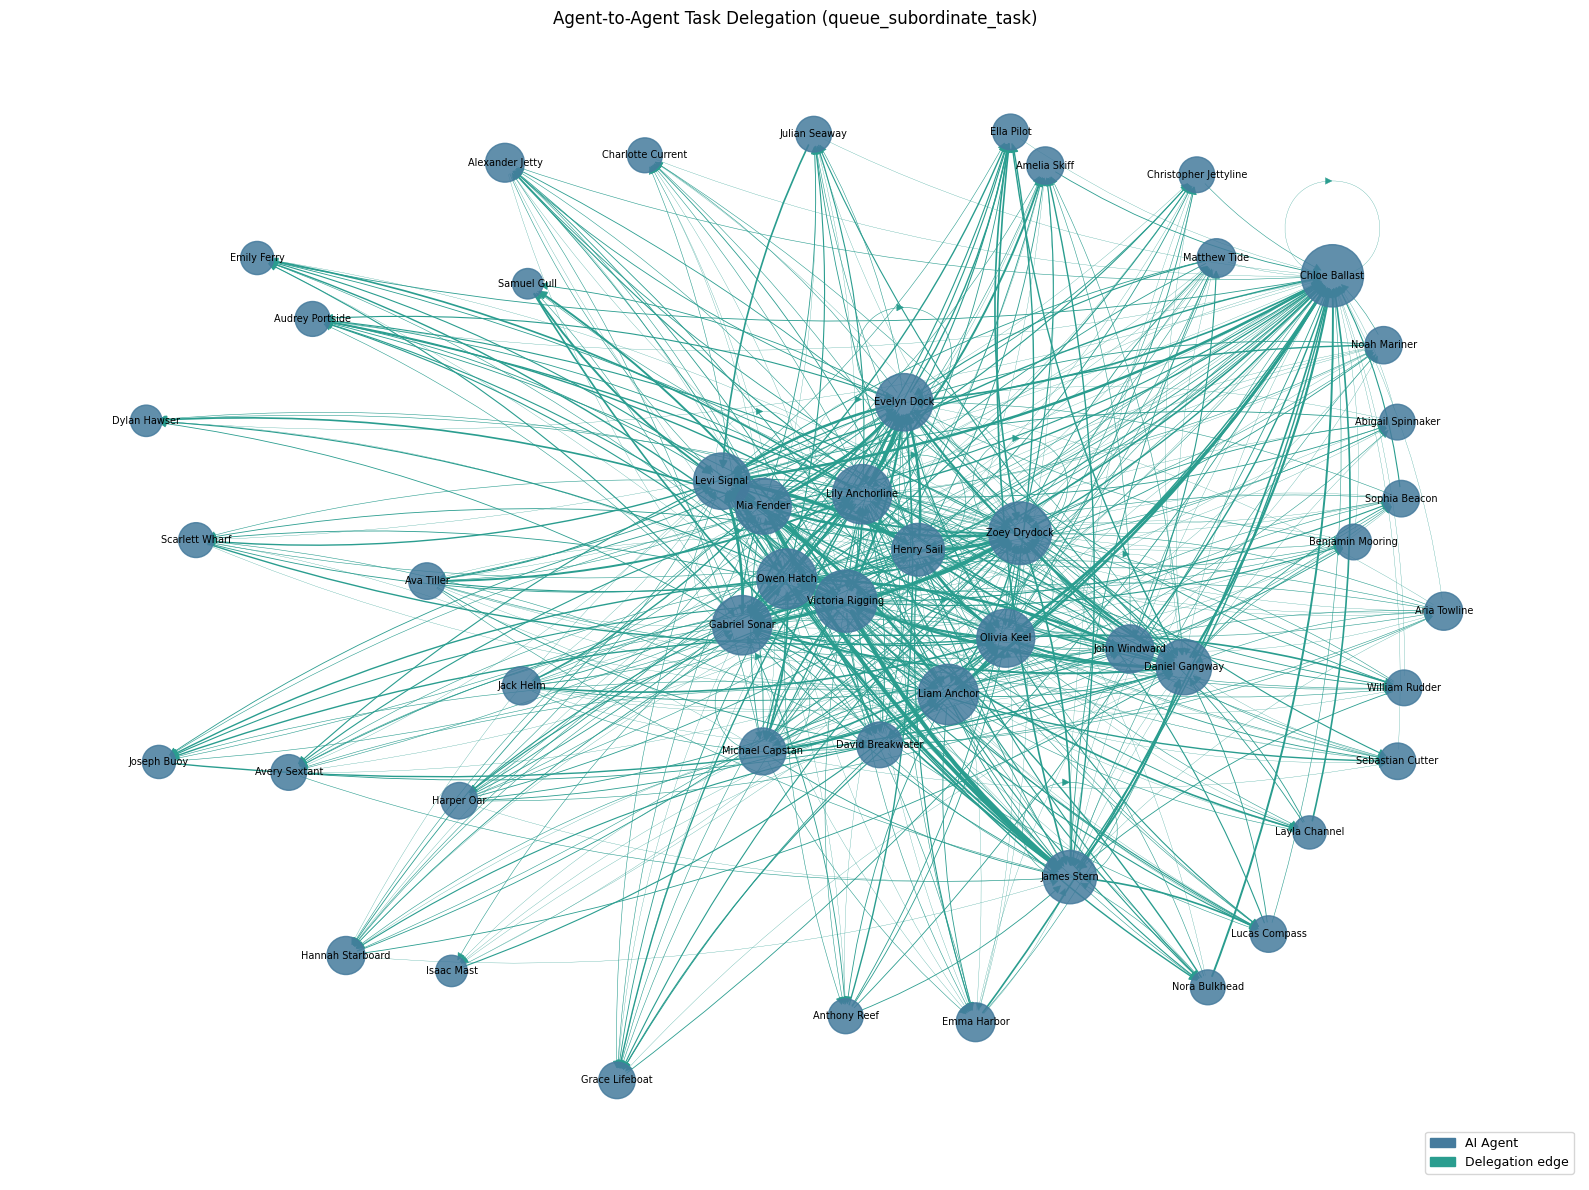

In [45]:
G2 = nx.DiGraph()
for e in events:
    if e["short_name"] == "queue_subordinate_task":
        agents = [p for p in e["parties"] if p.startswith("Agent/")]
        if len(agents) == 2:
            src, tgt = agents[0], agents[1]
            if G2.has_edge(src, tgt):
                G2[src][tgt]["weight"] += 1
            else:
                G2.add_edge(src, tgt, weight=1)

short = lambda n: n.replace("Agent/person:", "").replace("_", " ").title()
labels2 = {n: short(n) for n in G2.nodes}
weights = [G2[u][v]["weight"] for u, v in G2.edges]
sizes2 = [300 + G2.degree(n) * 30 for n in G2.nodes]

pos2 = nx.spring_layout(G2, seed=42, k=2.5)
fig, ax = plt.subplots(figsize=(16, 12))
nx.draw_networkx_nodes(G2, pos2, node_size=sizes2, node_color="#457B9D", alpha=0.85, ax=ax)
nx.draw_networkx_labels(G2, pos2, labels=labels2, font_size=7, ax=ax)
nx.draw_networkx_edges(
    G2, pos2,
    width=[w / max(weights) * 3 for w in weights],
    edge_color="#2A9D8F",
    arrows=True,
    arrowsize=12,
    connectionstyle="arc3,rad=0.1",
    ax=ax,
)
legend2 = [
    mpatches.Patch(color="#457B9D", label="AI Agent"),
    mpatches.Patch(color="#2A9D8F", label="Delegation edge"),
]
ax.legend(handles=legend2, loc="lower right", fontsize=9)
ax.set_title("Agent-to-Agent Task Delegation (queue_subordinate_task)")
ax.axis("off")
plt.tight_layout()
plt.show()

#### 5. Daily Heatmap — AI event counts per person

> Heatmap of AI-involved event counts per (person × day). Color intensity = event count (Blues scale). Makes activity spikes, idle periods, and anomalous days immediately visible.

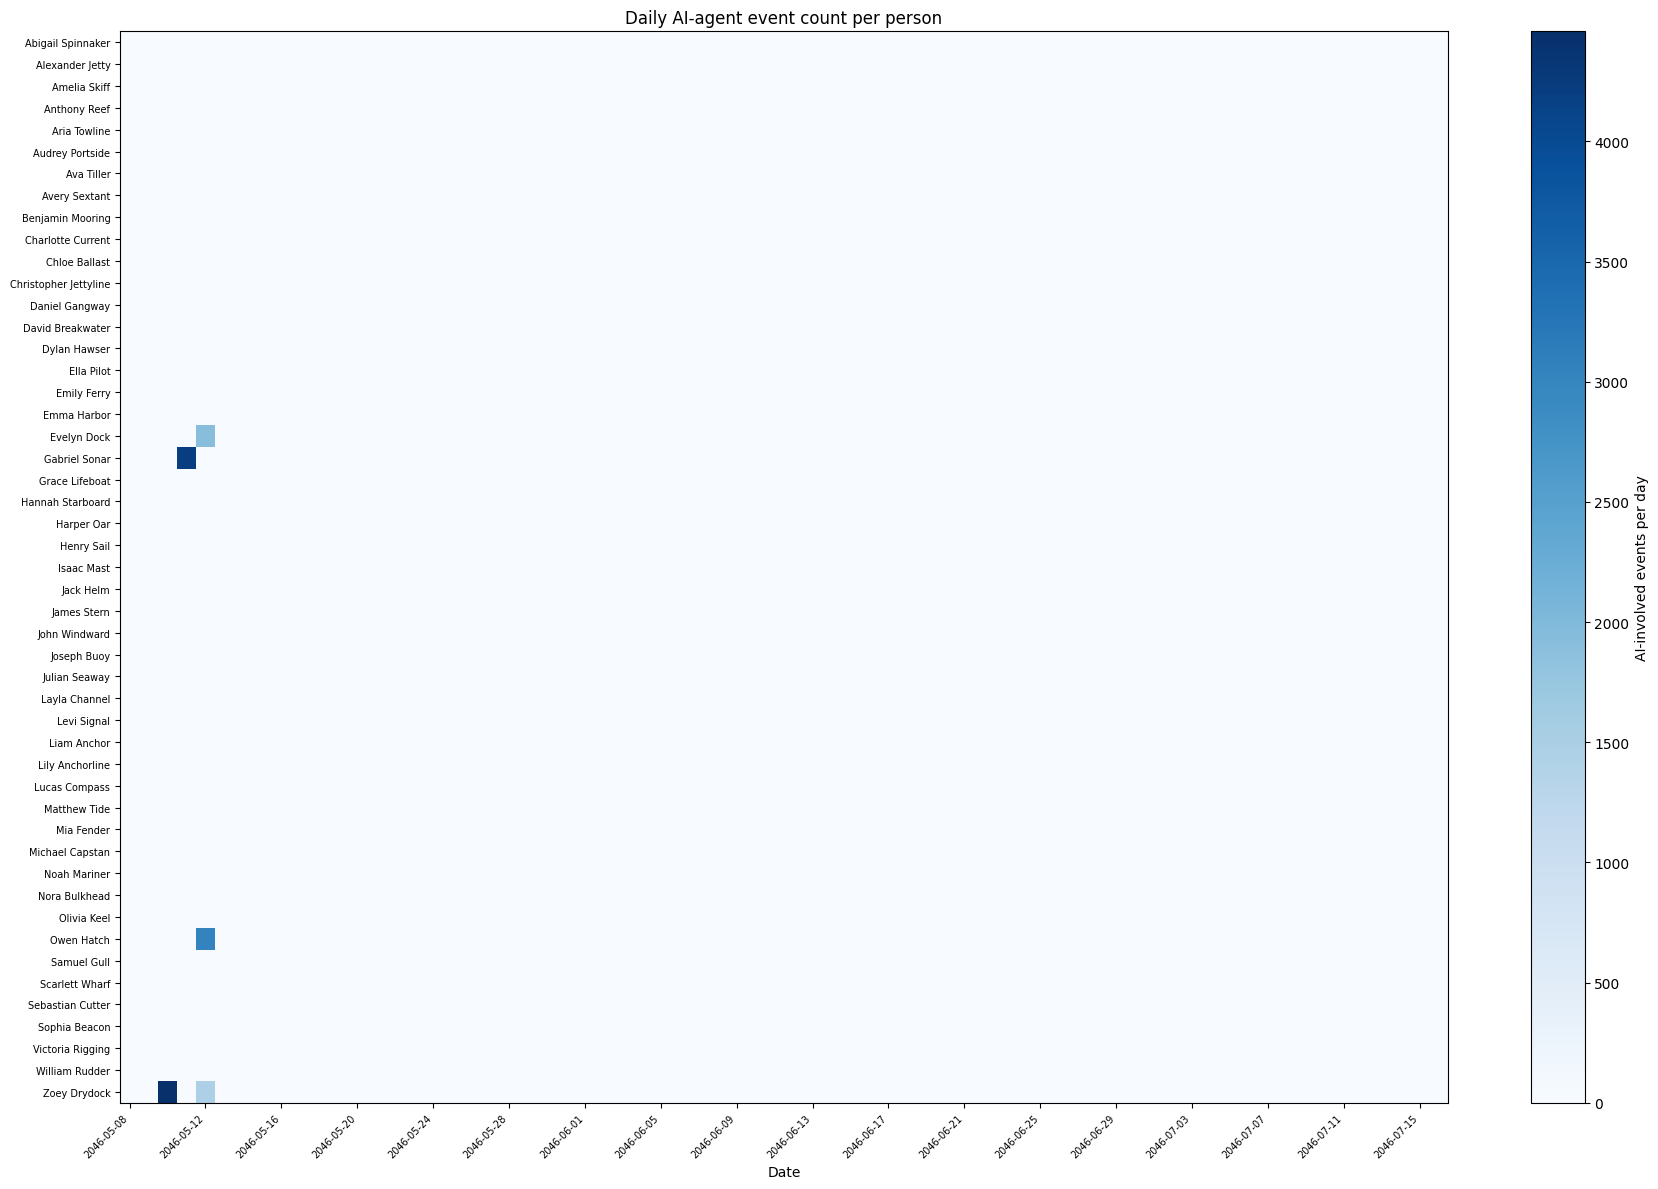

In [46]:
from collections import defaultdict
import datetime

ai_events = [e for e in events if any(p.startswith("Agent/") for p in e["parties"])]

person_day = defaultdict(lambda: defaultdict(int))
for e in ai_events:
    day = datetime.datetime.fromtimestamp(e["when"]).date()
    for p in e["parties"]:
        if p.startswith("person:"):
            person_day[p][day] += 1

all_days = sorted({datetime.datetime.fromtimestamp(e["when"]).date() for e in events})
all_persons = sorted(person_day.keys())
plabels5 = [p.replace("person:", "").replace("_", " ").title() for p in all_persons]

mat5 = np.array([[person_day[p].get(d, 0) for d in all_days] for p in all_persons])

step = max(1, len(all_days) // 15)
fig, ax = plt.subplots(figsize=(18, 12))
im = ax.imshow(mat5, aspect="auto", cmap="Blues", interpolation="nearest")
ax.set_yticks(range(len(plabels5)))
ax.set_yticklabels(plabels5, fontsize=7)
ax.set_xticks(range(0, len(all_days), step))
ax.set_xticklabels([str(all_days[i]) for i in range(0, len(all_days), step)], rotation=45, ha="right", fontsize=7)
ax.set_title("Daily AI-agent event count per person")
ax.set_xlabel("Date")
plt.colorbar(im, ax=ax, label="AI-involved events per day")
plt.tight_layout()
plt.show()

#### 7. Volume Trend — AI vs. human events over time

> Line chart of daily event counts for AI-involved, human-only, and A2A delegation streams over the full observation period. Shows overall system load and whether AI activity tracks or diverges from human activity.

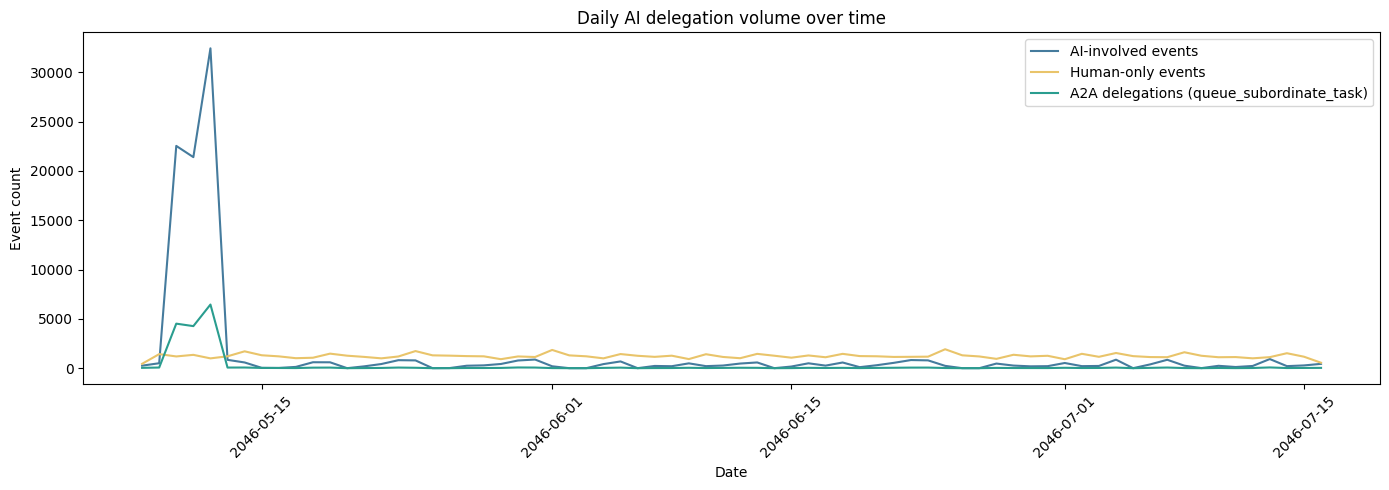

In [47]:
daily_ai    = defaultdict(int)
daily_human = defaultdict(int)
daily_a2a   = defaultdict(int)

for e in events:
    day = datetime.datetime.fromtimestamp(e["when"]).date()
    if any(p.startswith("Agent/") for p in e["parties"]):
        daily_ai[day] += 1
    else:
        daily_human[day] += 1
    if e["short_name"] == "queue_subordinate_task":
        daily_a2a[day] += 1

ai_series  = [daily_ai.get(d, 0)    for d in all_days]
hu_series  = [daily_human.get(d, 0) for d in all_days]
a2a_series = [daily_a2a.get(d, 0)   for d in all_days]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(all_days, ai_series,  color="#457B9D", label="AI-involved events")
ax.plot(all_days, hu_series,  color="#E9C46A", label="Human-only events")
ax.plot(all_days, a2a_series, color="#2A9D8F", label="A2A delegations (queue_subordinate_task)")
ax.set_xlabel("Date")
ax.set_ylabel("Event count")
ax.set_title("Daily AI delegation volume over time")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 8. Complexity Trend — avg parties & recursive delegations over time

> Dual-axis chart: average number of parties per AI event (line, left axis) and count of recursive A2A delegations (bar, right axis). Tracks how delegation depth and breadth evolve day by day.

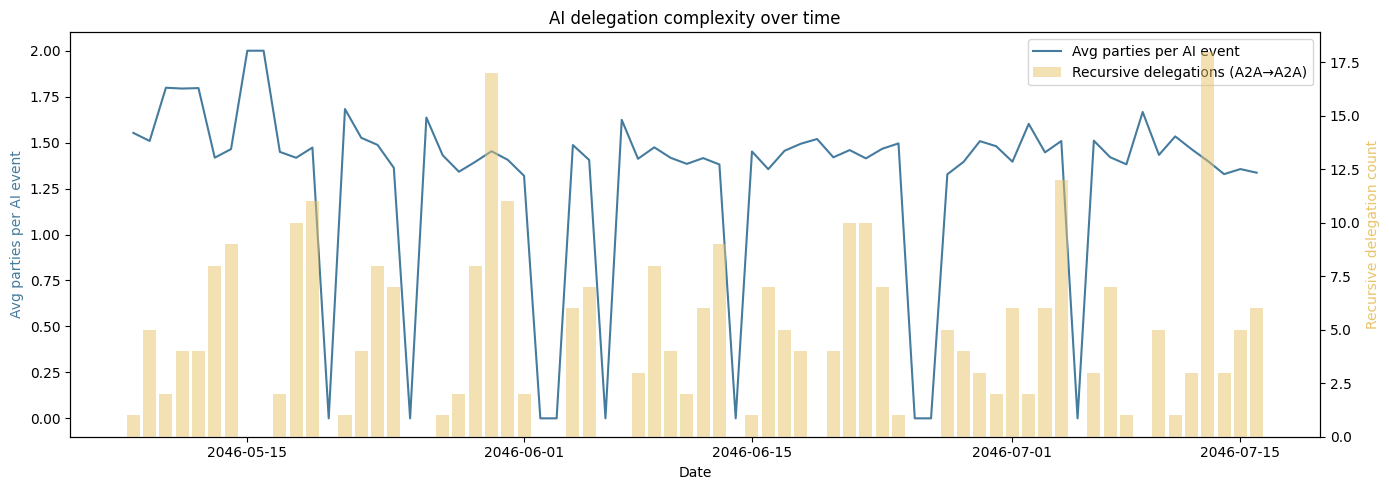

In [48]:
daily_parties   = defaultdict(list)
daily_recursive = defaultdict(int)

for e in events:
    day = datetime.datetime.fromtimestamp(e["when"]).date()
    if any(p.startswith("Agent/") for p in e["parties"]):
        daily_parties[day].append(len(e["parties"]))
    if e["short_name"] == "queue_subordinate_task" and e["details"].get("task") == "queue_subordinate_task":
        daily_recursive[day] += 1

avg_parties  = [np.mean(daily_parties.get(d, [0])) for d in all_days]
recursive_ct = [daily_recursive.get(d, 0)          for d in all_days]

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()
ax1.plot(all_days, avg_parties,  color="#457B9D", label="Avg parties per AI event")
ax2.bar( all_days, recursive_ct, color="#E9C46A", alpha=0.5, label="Recursive delegations (A2A→A2A)")
ax1.set_xlabel("Date")
ax1.set_ylabel("Avg parties per AI event", color="#457B9D")
ax2.set_ylabel("Recursive delegation count",  color="#E9C46A")
ax1.set_title("AI delegation complexity over time")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 9. Workload Origin — human-assigned vs. AI-delegated tasks per agent

> Per-agent stacked bar split by task source: tasks received from humans (`assign_agent_task`) vs. from other agents (`queue_subordinate_task`). Highlights agents that operate almost entirely on AI-issued instructions.

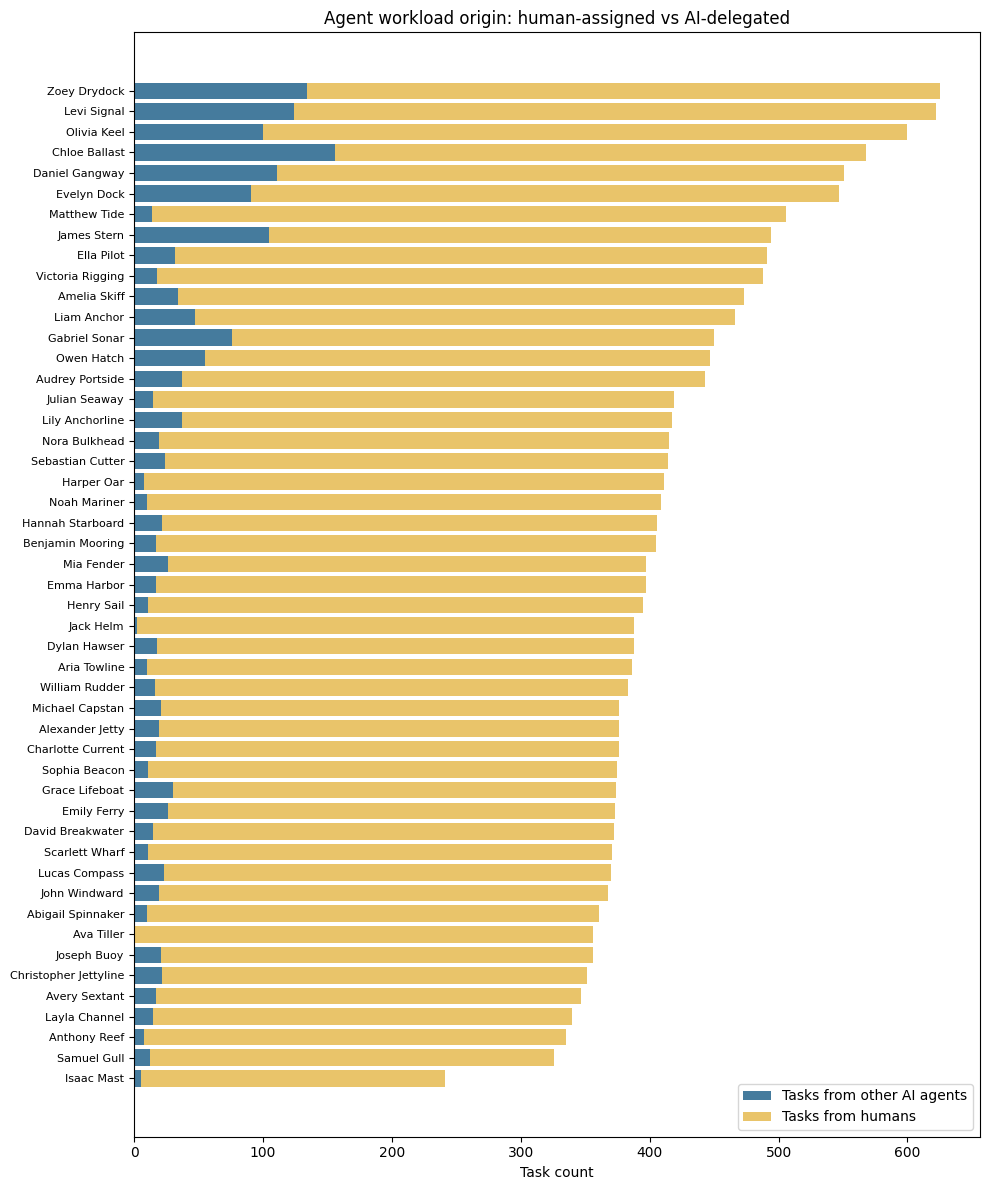

In [49]:
human_assigned = Counter()
for e in events:
    if e["short_name"] == "assign_agent_task":
        person = e["details"].get("person", "")
        if person:
            human_assigned["Agent/" + person] += 1

ai_delegated_recv = Counter()
for e in events:
    if e["short_name"] == "queue_subordinate_task":
        ags = [p for p in e["parties"] if p.startswith("Agent/")]
        if len(ags) == 2:
            ai_delegated_recv[ags[1]] += 1

all_agents9 = sorted(set(human_assigned) | set(ai_delegated_recv))
h_vals = [human_assigned.get(a, 0)    for a in all_agents9]
a_vals = [ai_delegated_recv.get(a, 0) for a in all_agents9]
totals9 = [h + a for h, a in zip(h_vals, a_vals)]

order9 = np.argsort(totals9)
all_agents9 = [all_agents9[i] for i in order9]
h_vals      = [h_vals[i]      for i in order9]
a_vals      = [a_vals[i]      for i in order9]
alabels9    = [a.replace("Agent/person:", "").replace("_", " ").title() for a in all_agents9]

y9 = np.arange(len(all_agents9))
fig, ax = plt.subplots(figsize=(10, 12))
ax.barh(y9, a_vals, color="#457B9D", label="Tasks from other AI agents")
ax.barh(y9, h_vals, left=a_vals, color="#E9C46A", label="Tasks from humans")
ax.set_yticks(y9)
ax.set_yticklabels(alabels9, fontsize=8)
ax.set_xlabel("Task count")
ax.set_title("Agent workload origin: human-assigned vs AI-delegated")
ax.legend()
plt.tight_layout()
plt.show()